# Gold Daily - Exploratory Data Analysis

This notebook explores the Gold Daily price dataset.

**Dataset:** `gold-daily.csv`

**Description:** Daily gold price data (Spanish format) including last price, open, high, low, volume, and percentage change from 2005 to present.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_PATH = Path('../../data/raw/gold-daily.csv')

## 1. Load and Clean Data

In [2]:
# Load dataset
df = pd.read_csv(DATA_PATH)

# Display first rows
print("First 5 rows (raw):")
display(df.head())

# Clean column names (Spanish to English)
df.columns = ['Date', 'Last', 'Open', 'High', 'Low', 'Vol.', 'Change %']

# Parse date (format: DD.MM.YYYY)
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')

# Clean numeric columns (Spanish format: comma as decimal separator, dot as thousands)
numeric_cols = ['Last', 'Open', 'High', 'Low']
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)

# Clean Volume column (handles K, M, B suffixes)
def clean_volume(v):
    if pd.isna(v) or v == '' or v == '-':
        return np.nan
    v = str(v).replace('.', '').replace(',', '.').upper()
    if 'K' in v:
        return float(v.replace('K', '')) * 1e3
    if 'M' in v:
        return float(v.replace('M', '')) * 1e6
    if 'B' in v:
        return float(v.replace('B', '')) * 1e9
    try:
        return float(v)
    except:
        return np.nan

if 'Vol.' in df.columns:
    df['Vol.'] = df['Vol.'].apply(clean_volume)

# Clean percentage column
df['Change %'] = df['Change %'].str.replace('%', '').str.replace(',', '.').astype(float)

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

print("\nCleaned dataset:")
display(df.head())
print("\nData types:")
print(df.dtypes)

First 5 rows (raw):


,Fecha,Último,Apertura,Máximo,Mínimo,Vol.,% var.
0,31.01.2005,"424,10","428,30","428,90","421,50","65,84K","-0,93%"
1,01.02.2005,"422,90","424,30","424,60","421,40","38,34K","-0,28%"
2,02.02.2005,"423,00","422,70","424,70","421,90","22,30K","0,02%"
3,03.02.2005,"418,50","422,80","423,90","416,20","55,31K","-1,06%"
4,04.02.2005,"415,90","418,60","419,50","415,50","49,62K","-0,62%"



Cleaned dataset:


,Date,Last,Open,High,Low,Vol.,Change %
0,2005-01-31,424.1,428.3,428.9,421.5,65840.0,-0.93
1,2005-02-01,422.9,424.3,424.6,421.4,38340.0,-0.28
2,2005-02-02,423.0,422.7,424.7,421.9,22300.0,0.02
3,2005-02-03,418.5,422.8,423.9,416.2,55310.0,-1.06
4,2005-02-04,415.9,418.6,419.5,415.5,49620.0,-0.62



Data types:
Date        datetime64[ns]
Last               float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object


## 2. Data Overview

In [3]:
print("Dataset Shape:", df.shape)
print("\nDate range:", df['Date'].min(), "to", df['Date'].max())
print("Total trading days:", len(df))
print("\nDataset Info:")
df.info()

Dataset Shape: (4966, 7)

Date range: 2005-01-31 00:00:00 to 2026-02-04 00:00:00
Total trading days: 4966

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4966 entries, 0 to 4965
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4966 non-null   datetime64[ns]
 1   Last      4966 non-null   float64       
 2   Open      4966 non-null   float64       
 3   High      4966 non-null   float64       
 4   Low       4966 non-null   float64       
 5   Vol.      4964 non-null   float64       
 6   Change %  4966 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 271.7 KB


## 3. Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print("Missing Values Summary:")
display(missing_df[missing_df['Missing Count'] > 0])
if missing.sum() == 0:
    print("\n✓ No missing values found!")

Missing Values Summary:


,Missing Count,Percentage
Vol.,2,0.040274


## 4. Descriptive Statistics

In [5]:
print("Descriptive Statistics:")
display(df[['Last', 'Open', 'High', 'Low', 'Vol.', 'Change %']].describe())

Descriptive Statistics:


,Last,Open,High,Low,Vol.,Change %
count,4966.000000,4966.000000,4966.000000,4966.000000,4964.000000,4966.000000
mean,1427.216331,1427.026281,1438.431794,1415.295797,159215.034247,0.056776
std,677.201378,676.461241,683.417713,670.163987,98864.048998,1.177458
min,414.300000,414.000000,415.300000,411.500000,0.000000,-11.390000
25%,1080.675000,1079.325000,1088.350000,1071.375000,95682.500000,-0.500000
50%,1303.150000,1303.150000,1311.700000,1293.500000,150825.000000,0.050000
75%,1737.375000,1737.425000,1751.525000,1723.525000,210492.500000,0.670000
max,5354.800000,5449.900000,5626.800000,5175.000000,816530.000000,8.970000


## 5. Price Time Series

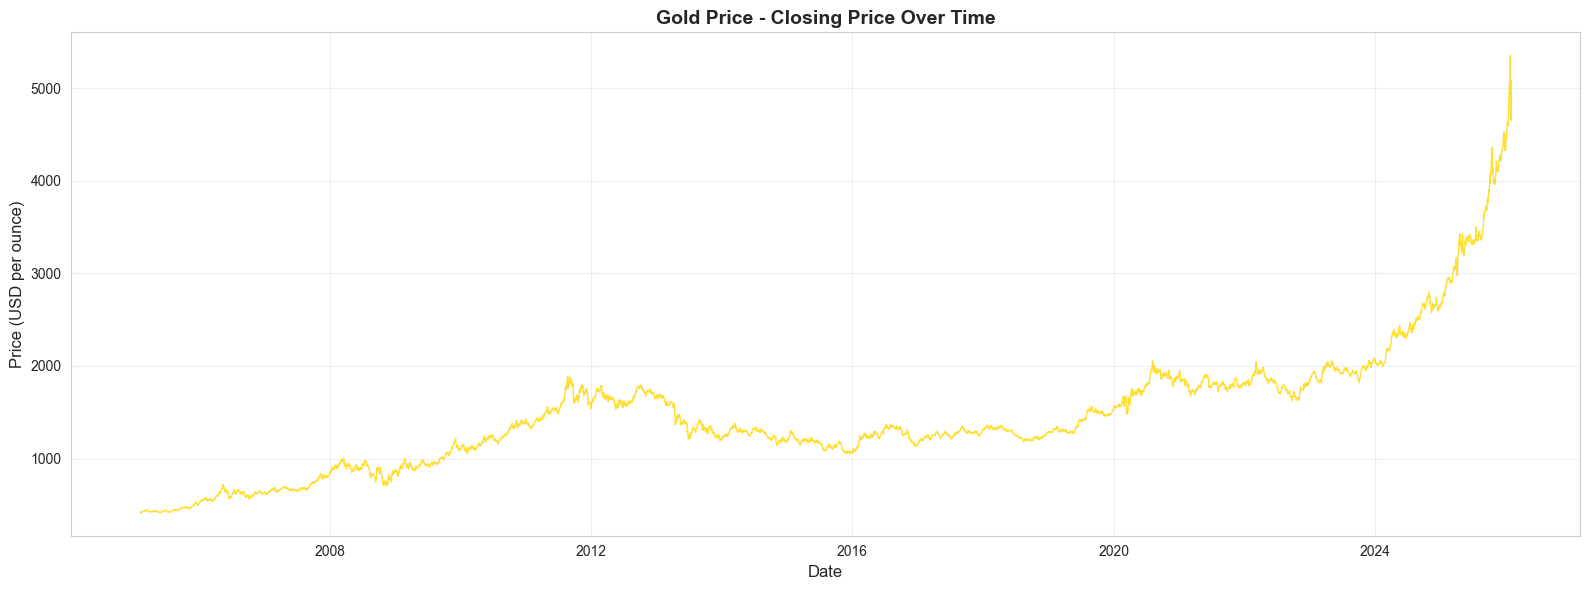

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Last'], linewidth=1, alpha=0.8, color='gold')
ax.set_title('Gold Price - Closing Price Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD per ounce)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

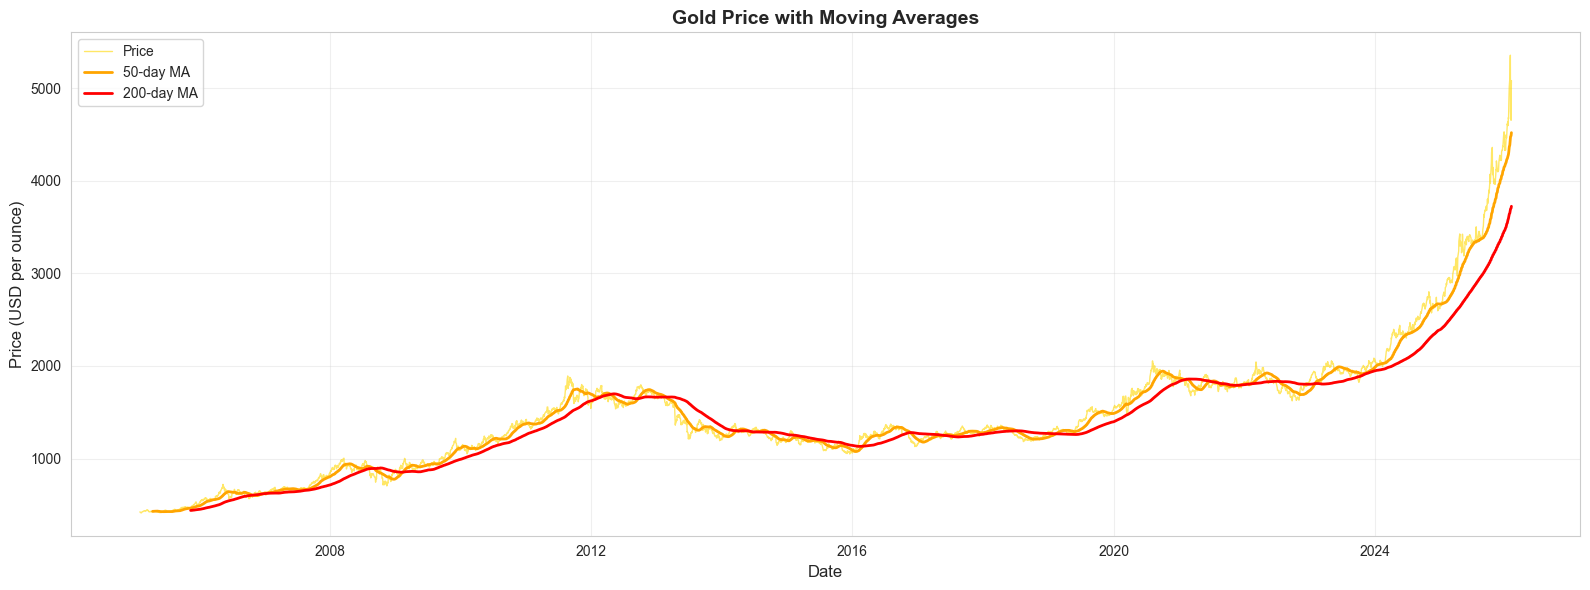

In [7]:
# Moving averages
df['MA_50'] = df['Last'].rolling(window=50).mean()
df['MA_200'] = df['Last'].rolling(window=200).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Last'], linewidth=1, alpha=0.6, label='Price', color='gold')
ax.plot(df['Date'], df['MA_50'], linewidth=2, label='50-day MA', color='orange')
ax.plot(df['Date'], df['MA_200'], linewidth=2, label='200-day MA', color='red')
ax.set_title('Gold Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD per ounce)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Returns Analysis

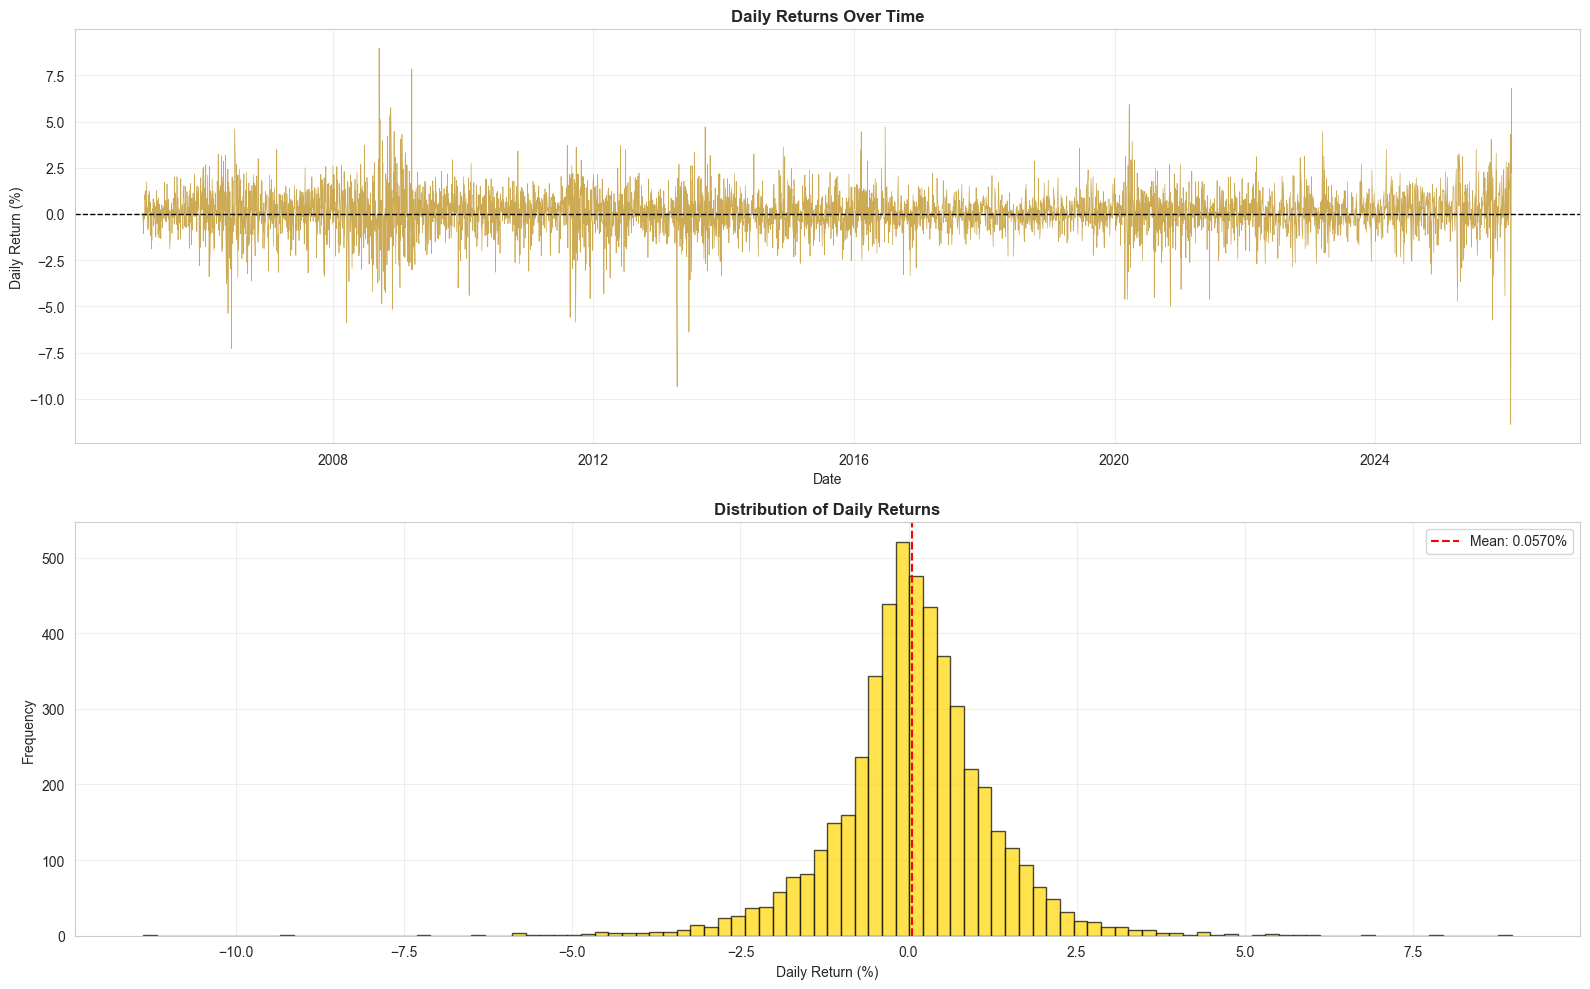

In [8]:
df['Daily_Return'] = df['Last'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(df['Date'], df['Daily_Return'], linewidth=0.5, alpha=0.7, color='darkgoldenrod')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Daily Returns Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily Return (%)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['Daily_Return'].dropna(), bins=100, edgecolor='black', alpha=0.7, color='gold')
axes[1].axvline(df['Daily_Return'].mean(), color='red', linestyle='--', label=f'Mean: {df["Daily_Return"].mean():.4f}%')
axes[1].set_title('Distribution of Daily Returns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Volatility Analysis

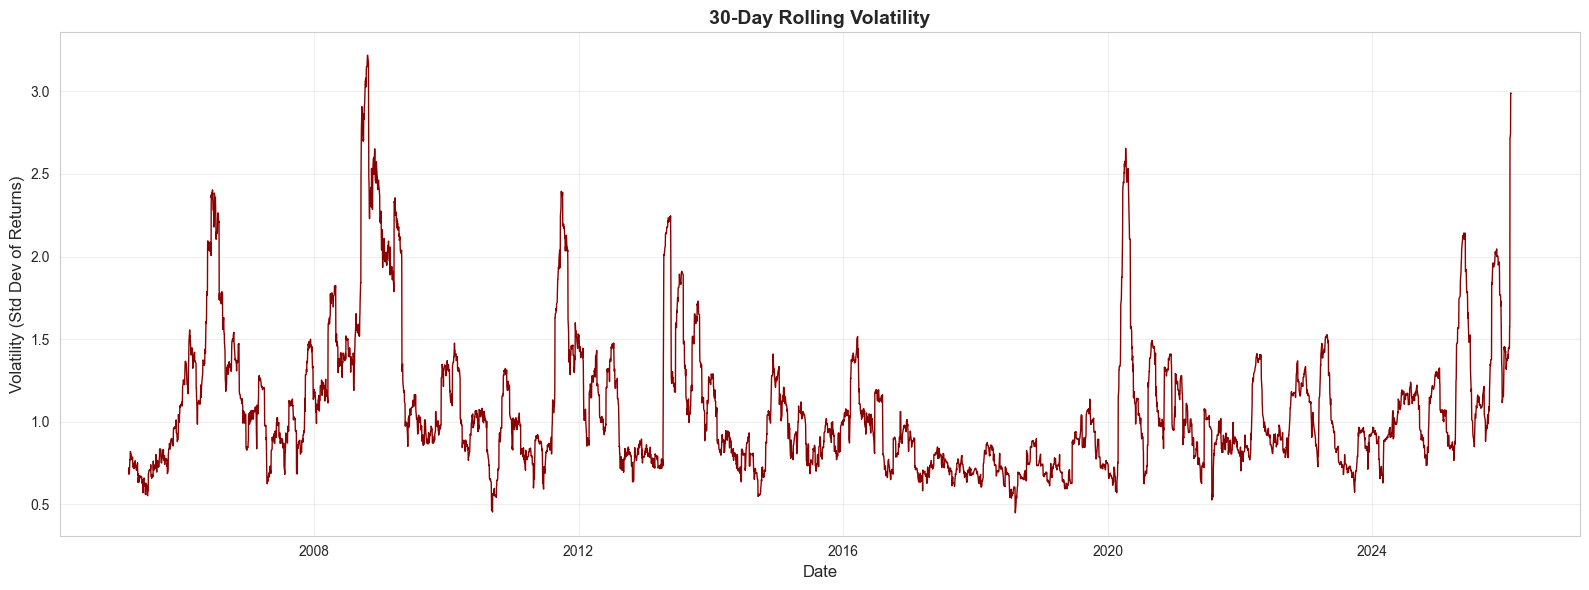

In [9]:
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Volatility_30d'], linewidth=1, color='darkred')
ax.set_title('30-Day Rolling Volatility', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility (Std Dev of Returns)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Volume Analysis

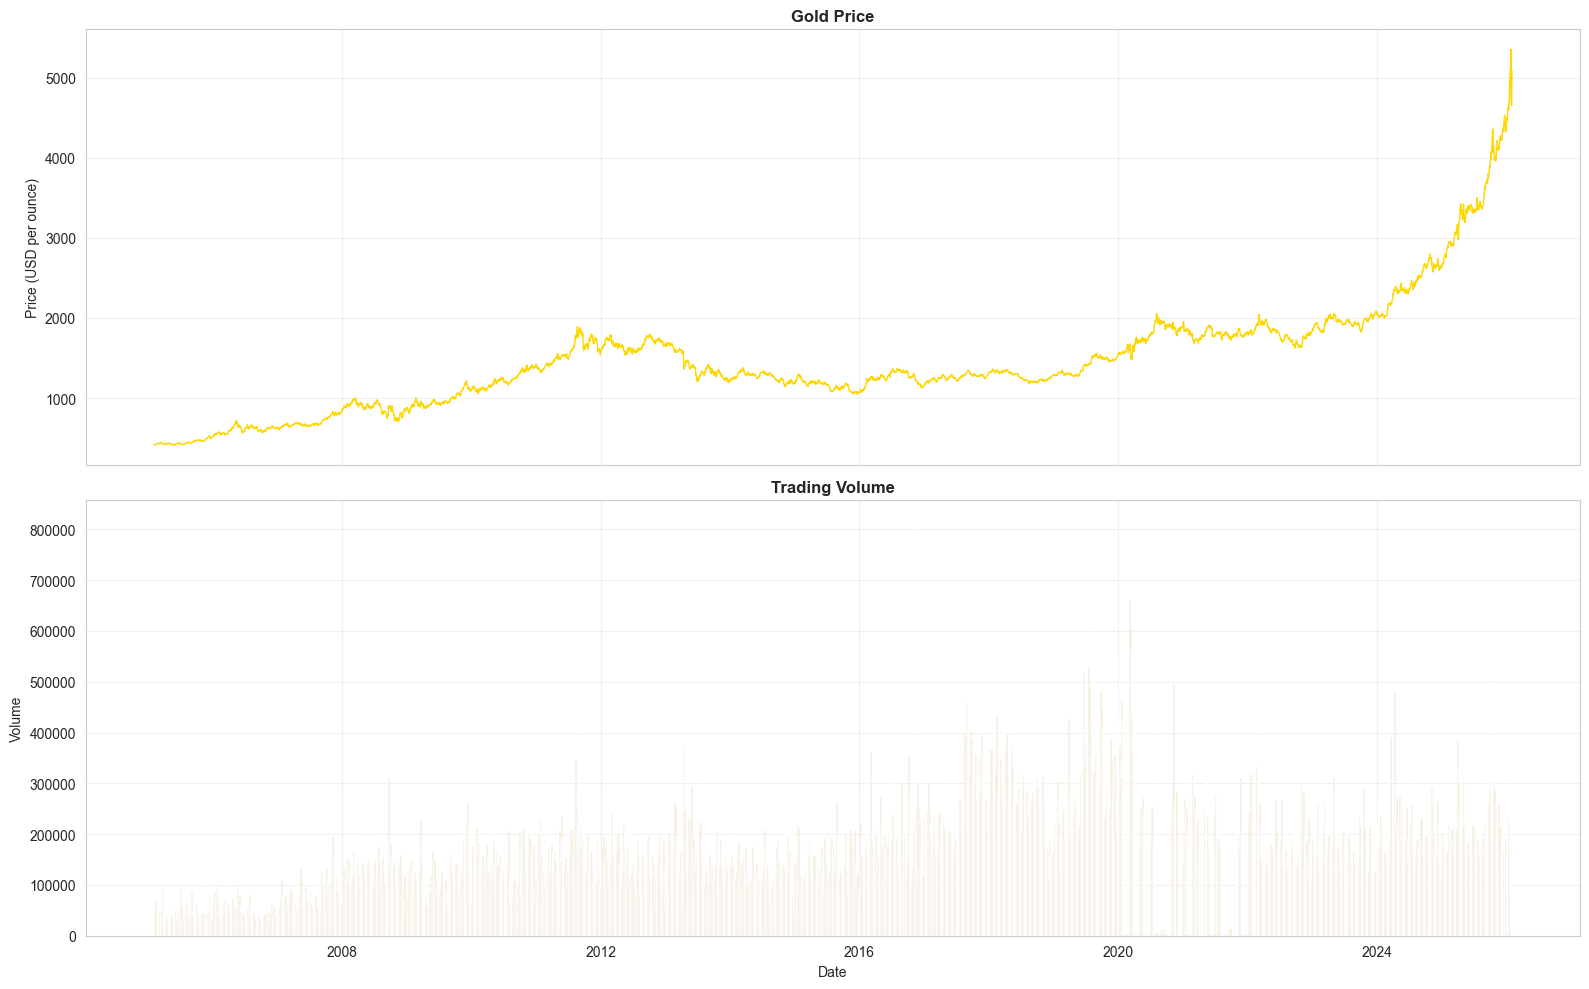

In [10]:
# Plot trading volume
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Price
axes[0].plot(df['Date'], df['Last'], linewidth=1, color='gold')
axes[0].set_title('Gold Price', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (USD per ounce)')
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(df['Date'], df['Vol.'], width=1, alpha=0.7, color='darkgoldenrod')
axes[1].set_title('Trading Volume', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Yearly Performance

Yearly Statistics:


,mean,std,min,max,count
Year,,,,,
2005,448.938793,28.046985,414.3,531.5,232
2006,608.086400,39.890175,527.8,721.5,250
2007,701.321484,59.340917,606.9,842.7,256
2008,874.174902,67.829659,705.0,1004.3,255
2009,974.966270,85.291449,807.3,1218.3,252
2010,1228.338889,98.887188,1052.8,1421.4,252
2011,1573.286508,148.272642,1318.4,1891.9,252
2012,1670.522619,63.887511,1536.6,1796.5,252
2013,1408.720238,146.845567,1193.6,1693.2,252


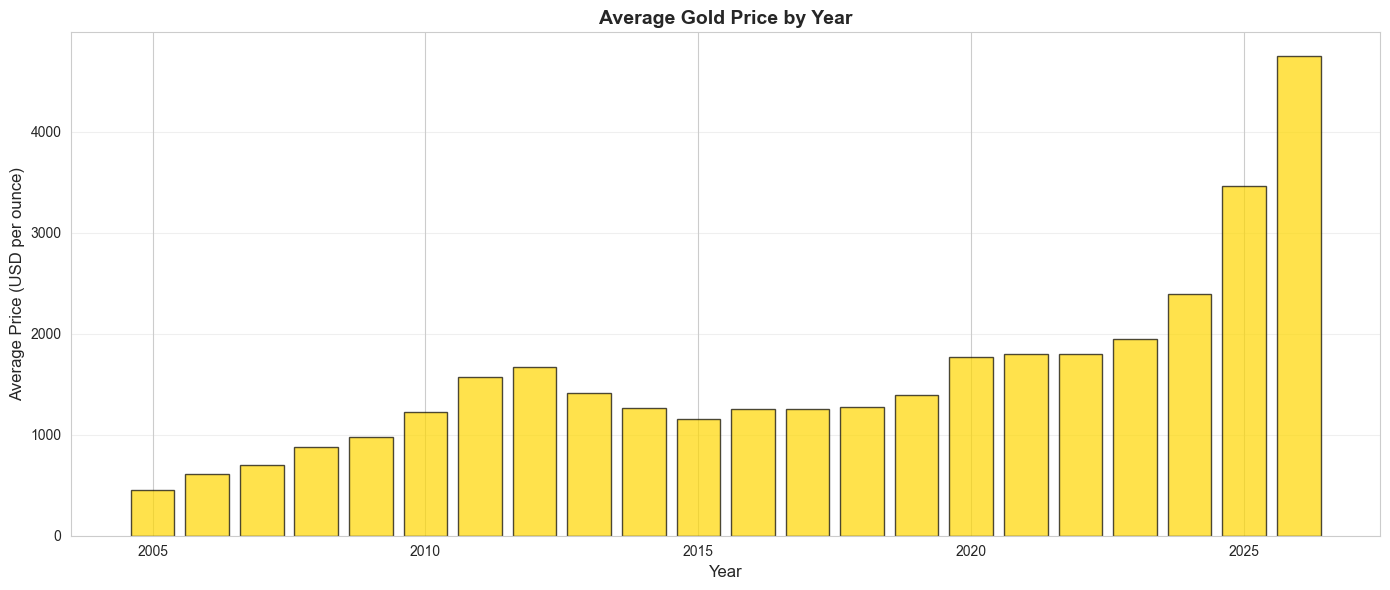

In [11]:
# Extract year
df['Year'] = df['Date'].dt.year

# Yearly statistics
yearly_stats = df.groupby('Year')['Last'].agg(['mean', 'std', 'min', 'max', 'count'])
print("Yearly Statistics:")
display(yearly_stats)

# Plot yearly average
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(yearly_stats.index, yearly_stats['mean'], alpha=0.7, edgecolor='black', color='gold')
ax.set_title('Average Gold Price by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Price (USD per ounce)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 10. Major Price Movements

In [12]:
# Identify major peaks and troughs
top_10_prices = df.nlargest(10, 'Last')[['Date', 'Last']]
print("Top 10 Highest Prices:")
display(top_10_prices)

bottom_10_prices = df.nsmallest(10, 'Last')[['Date', 'Last']]
print("\nTop 10 Lowest Prices:")
display(bottom_10_prices)

Top 10 Highest Prices:


,Date,Last
4961,2026-01-29,5354.80
4960,2026-01-28,5321.00
4958,2026-01-26,5102.40
4959,2026-01-27,5101.40
4965,2026-02-04,5080.99
4957,2026-01-23,5017.00
4964,2026-02-03,4969.20
4956,2026-01-22,4949.40
4955,2026-01-21,4873.10
4954,2026-01-20,4800.80



Top 10 Lowest Prices:


,Date,Last
6,2005-02-08,414.3
7,2005-02-09,414.5
5,2005-02-07,415.4
4,2005-02-04,415.9
78,2005-05-23,416.9
77,2005-05-20,417.7
79,2005-05-24,417.7
84,2005-06-01,417.7
81,2005-05-26,418.0
3,2005-02-03,418.5


## 11. Crisis Periods Analysis
- Can we consider these last days market price drop as a crisis? #TODO: ask Inés

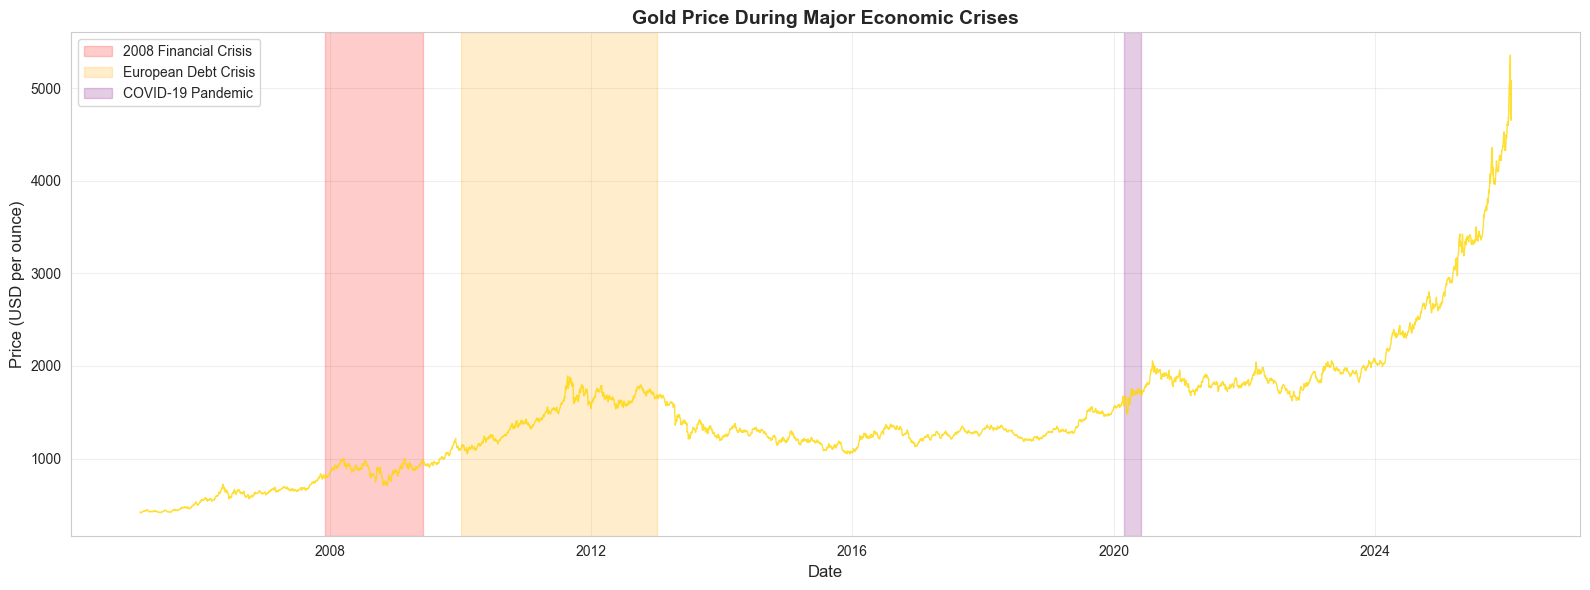

In [13]:
# Highlight major financial crises
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Last'], linewidth=1, alpha=0.8, color='gold')

# Mark major events
ax.axvspan(pd.Timestamp('2007-12-01'), pd.Timestamp('2009-06-01'), alpha=0.2, color='red', label='2008 Financial Crisis')
ax.axvspan(pd.Timestamp('2010-01-01'), pd.Timestamp('2012-12-31'), alpha=0.2, color='orange', label='European Debt Crisis')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'), alpha=0.2, color='purple', label='COVID-19 Pandemic')

ax.set_title('Gold Price During Major Economic Crises', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD per ounce)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Correlation Analysis

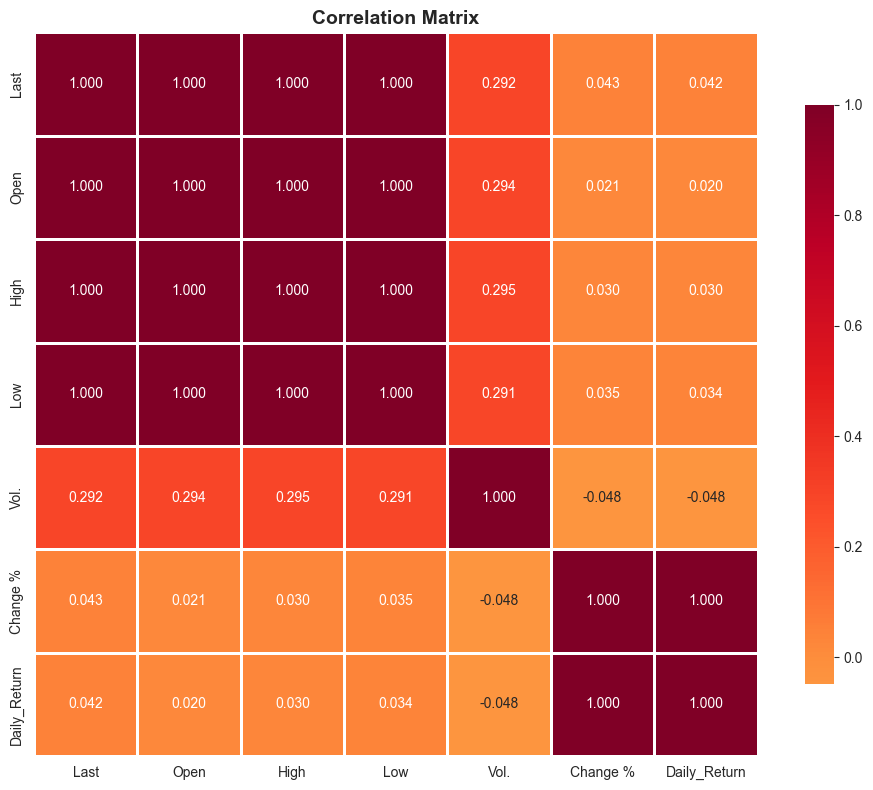

In [14]:
# Correlation matrix
corr_cols = ['Last', 'Open', 'High', 'Low', 'Vol.', 'Change %', 'Daily_Return']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='YlOrRd', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Summary

In [15]:
print("=" * 60)
print("KEY FINDINGS - GOLD DAILY")
print("=" * 60)
print(f"\n1. Dataset Coverage:")
print(f"   - Start: {df['Date'].min().strftime('%Y-%m-%d')}")
print(f"   - End: {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"   - Days: {len(df):,}")
print(f"\n2. Price Statistics:")
print(f"   - Current: ${df['Last'].iloc[-1]:,.2f}")
print(f"   - All-time High: ${df['Last'].max():,.2f} ({df.loc[df['Last'].idxmax(), 'Date'].strftime('%Y-%m-%d')})")
print(f"   - All-time Low: ${df['Last'].min():,.2f} ({df.loc[df['Last'].idxmin(), 'Date'].strftime('%Y-%m-%d')})")
print(f"   - Average: ${df['Last'].mean():,.2f}")
print(f"\n3. Returns:")
print(f"   - Avg Daily Return: {df['Daily_Return'].mean():.4f}%")
print(f"   - Volatility: {df['Daily_Return'].std():.4f}%")
print(f"   - Best Day: {df['Daily_Return'].max():.2f}% ({df.loc[df['Daily_Return'].idxmax(), 'Date'].strftime('%Y-%m-%d')})")
print(f"   - Worst Day: {df['Daily_Return'].min():.2f}% ({df.loc[df['Daily_Return'].idxmin(), 'Date'].strftime('%Y-%m-%d')})")
print(f"\n4. Growth:")
total_return = ((df['Last'].iloc[-1] / df['Last'].iloc[0]) - 1) * 100
print(f"   - Total Return: {total_return:,.2f}%")
print(f"\n5. Safe Haven Characteristics:")
print(f"   - Gold is traditionally viewed as a safe haven asset")
print(f"   - Price typically rises during economic uncertainty")
print(f"   - Lower volatility compared to stocks and cryptocurrencies")
print("\n" + "=" * 60)

KEY FINDINGS - GOLD DAILY

1. Dataset Coverage:
   - Start: 2005-01-31
   - End: 2026-02-04
   - Days: 4,966

2. Price Statistics:
   - Current: $5,080.99
   - All-time High: $5,354.80 (2026-01-29)
   - All-time Low: $414.30 (2005-02-08)
   - Average: $1,427.22

3. Returns:
   - Avg Daily Return: 0.0570%
   - Volatility: 1.1775%
   - Best Day: 8.97% (2008-09-17)
   - Worst Day: -11.39% (2026-01-30)

4. Growth:
   - Total Return: 1,098.06%

5. Safe Haven Characteristics:
   - Gold is traditionally viewed as a safe haven asset
   - Price typically rises during economic uncertainty
   - Lower volatility compared to stocks and cryptocurrencies

